# Experiment 4: Effect of Optimization on Generalization

### Objective
To investigate whether the choice of optimization algorithm affects the generalization behavior of an overparameterized neural network.

The experiment compares SGD and Adam using the same architecture and parameter count.

### Experimental Configuration

- Dataset: MNIST
- Width: 2048
- Parameters: 10,020,874
- Batch size: 128
- Epochs: 100
- Loss function: Cross-Entropy Loss
- Optimizers: SGD (learning rate 0.01) and Adam (learning rate 0.001)

Device: cuda
GPU: Tesla T4


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 458kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.97MB/s]



Training samples: 60000
Test samples: 10000

Model width: 2048
Total parameters: 10020874

Training with SGD
Learning rate: 0.01
Epoch  10/100 | Train Loss: 0.2533 | Train Acc: 92.80% | Test Loss: 0.2408 | Test Acc: 93.13% | Gap: -0.33%
Epoch  20/100 | Train Loss: 0.1538 | Train Acc: 95.66% | Test Loss: 0.1531 | Test Acc: 95.54% | Gap: 0.12%
Epoch  30/100 | Train Loss: 0.1029 | Train Acc: 97.10% | Test Loss: 0.1119 | Test Acc: 96.62% | Gap: 0.48%
Epoch  40/100 | Train Loss: 0.0718 | Train Acc: 98.01% | Test Loss: 0.0920 | Test Acc: 97.18% | Gap: 0.83%
Epoch  50/100 | Train Loss: 0.0513 | Train Acc: 98.66% | Test Loss: 0.0782 | Test Acc: 97.66% | Gap: 1.00%
Epoch  60/100 | Train Loss: 0.0366 | Train Acc: 99.11% | Test Loss: 0.0721 | Test Acc: 97.71% | Gap: 1.40%
Epoch  70/100 | Train Loss: 0.0264 | Train Acc: 99.44% | Test Loss: 0.0688 | Test Acc: 97.86% | Gap: 1.58%
Epoch  80/100 | Train Loss: 0.0190 | Train Acc: 99.67% | Test Loss: 0.0678 | Test Acc: 97.91% | Gap: 1.77%
Epoch  90/100

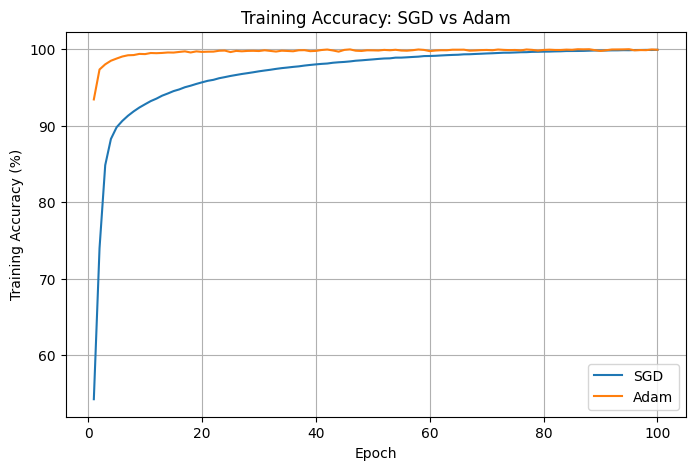

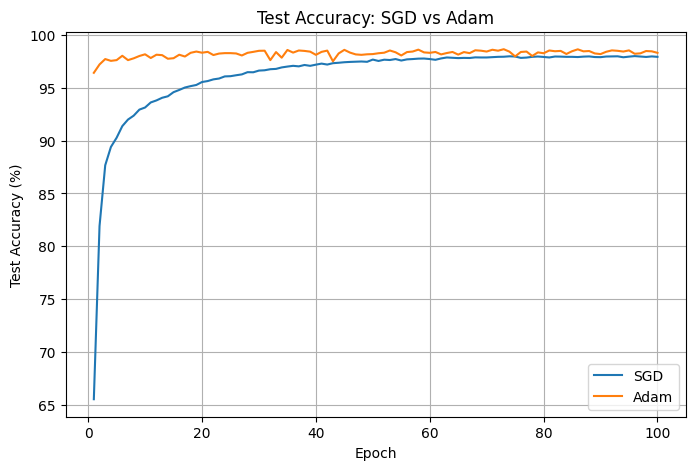

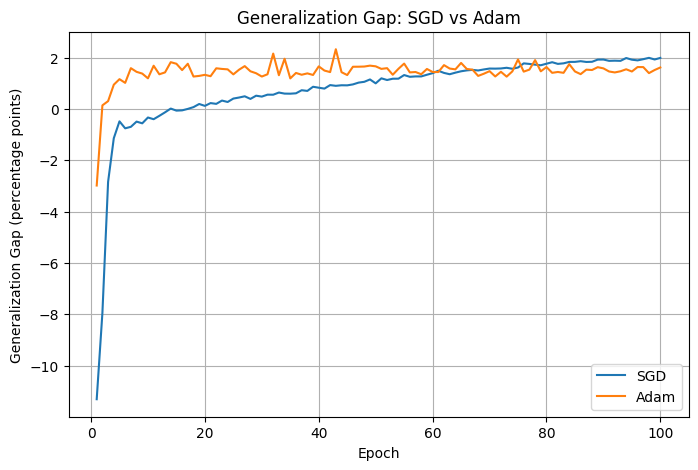

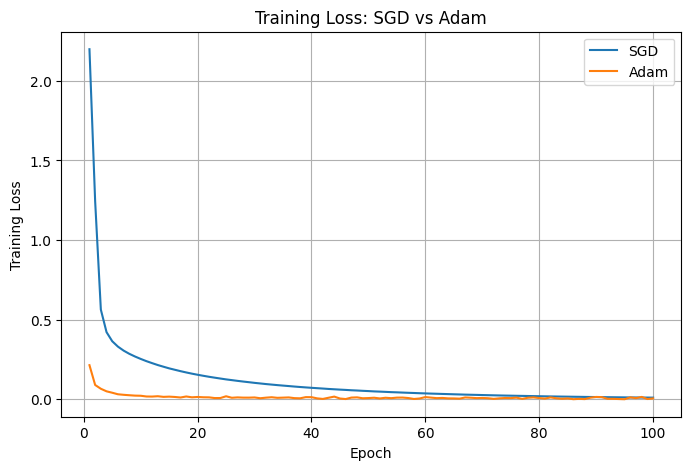

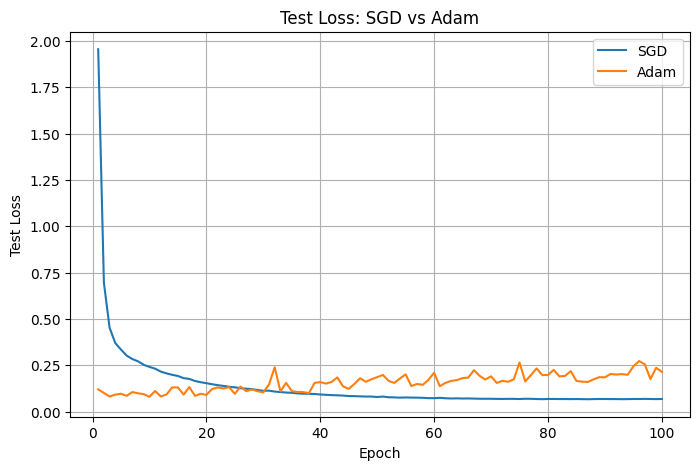

In [ ]:
# ============================================================
# EXPERIMENT 4
# Effect of Optimization on Generalization
# SGD vs Adam
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pandas as pd
import time
import matplotlib.pyplot as plt


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. RANDOM SEED
# ============================================================

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


# ============================================================
# 3. LOAD MNIST
# ============================================================

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# 4. DATA LOADERS
# ============================================================

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("\nTraining samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


# ============================================================
# 5. MODEL
# ============================================================

class MLP(nn.Module):

    def __init__(self, width):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, 10)
        )

    def forward(self, x):
        return self.network(x)


# ============================================================
# 6. PARAMETER COUNT
# ============================================================

width = 2048

temp_model = MLP(width)

num_parameters = sum(
    p.numel() for p in temp_model.parameters()
)

print("\nModel width:", width)
print("Total parameters:", num_parameters)

del temp_model


# ============================================================
# 7. TRAINING FUNCTION
# ============================================================

def train_model(optimizer_name, learning_rate, epochs=100):

    print("\n" + "=" * 60)
    print(f"Training with {optimizer_name}")
    print(f"Learning rate: {learning_rate}")
    print("=" * 60)

    model = MLP(width).to(device)

    criterion = nn.CrossEntropyLoss()

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    if optimizer_name == "SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    else:
        raise ValueError("Unknown optimizer")

    history = []

    start_time = time.time()

    # ========================================================
    # TRAINING LOOP
    # ========================================================

    for epoch in range(epochs):

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            train_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            train_correct += (
                predictions == labels
            ).sum().item()

            train_total += labels.size(0)

        train_loss /= train_total

        train_accuracy = (
            100 * train_correct / train_total
        )

        # ----------------------------------------------------
        # Evaluation
        # ----------------------------------------------------

        model.eval()

        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                test_loss += (
                    loss.item() * images.size(0)
                )

                predictions = outputs.argmax(dim=1)

                test_correct += (
                    predictions == labels
                ).sum().item()

                test_total += labels.size(0)

        test_loss /= test_total

        test_accuracy = (
            100 * test_correct / test_total
        )

        # ----------------------------------------------------
        # Generalization gap
        # ----------------------------------------------------

        generalization_gap = (
            train_accuracy - test_accuracy
        )

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        history.append({

            "epoch": epoch + 1,

            "train_loss": train_loss,

            "train_accuracy": train_accuracy,

            "test_loss": test_loss,

            "test_accuracy": test_accuracy,

            "generalization_gap": generalization_gap
        })

        # ----------------------------------------------------
        # Print every 10 epochs
        # ----------------------------------------------------

        if (epoch + 1) % 10 == 0:

            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_accuracy:.2f}% | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_accuracy:.2f}% | "
                f"Gap: {generalization_gap:.2f}%"
            )

    runtime = time.time() - start_time

    print(
        f"\nTraining time: {runtime/60:.2f} minutes"
    )

    return model, history


# ============================================================
# 8. RUN SGD
# ============================================================

sgd_model, sgd_history = train_model(
    optimizer_name="SGD",
    learning_rate=0.01,
    epochs=100
)


# ============================================================
# 9. RUN ADAM
# ============================================================

adam_model, adam_history = train_model(
    optimizer_name="Adam",
    learning_rate=0.001,
    epochs=100
)


# ============================================================
# 10. CONVERT HISTORY TO DATAFRAMES
# ============================================================

sgd_df = pd.DataFrame(sgd_history)

adam_df = pd.DataFrame(adam_history)


# ============================================================
# 11. FINAL RESULTS
# ============================================================

final_results = pd.DataFrame({

    "Optimizer": [
        "SGD",
        "Adam"
    ],

    "Learning Rate": [
        0.01,
        0.001
    ],

    "Parameters": [
        num_parameters,
        num_parameters
    ],

    "Train Loss": [
        sgd_df.iloc[-1]["train_loss"],
        adam_df.iloc[-1]["train_loss"]
    ],

    "Train Accuracy": [
        sgd_df.iloc[-1]["train_accuracy"],
        adam_df.iloc[-1]["train_accuracy"]
    ],

    "Test Loss": [
        sgd_df.iloc[-1]["test_loss"],
        adam_df.iloc[-1]["test_loss"]
    ],

    "Test Accuracy": [
        sgd_df.iloc[-1]["test_accuracy"],
        adam_df.iloc[-1]["test_accuracy"]
    ],

    "Generalization Gap": [
        sgd_df.iloc[-1]["generalization_gap"],
        adam_df.iloc[-1]["generalization_gap"]
    ]
})


print("\n")
print("=" * 80)
print("FINAL RESULTS")
print("=" * 80)

print(
    final_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 12. PLOT TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    sgd_df["epoch"],
    sgd_df["train_accuracy"],
    label="SGD"
)

plt.plot(
    adam_df["epoch"],
    adam_df["train_accuracy"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy: SGD vs Adam")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 13. PLOT TEST ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    sgd_df["epoch"],
    sgd_df["test_accuracy"],
    label="SGD"
)

plt.plot(
    adam_df["epoch"],
    adam_df["test_accuracy"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy: SGD vs Adam")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 14. PLOT GENERALIZATION GAP
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    sgd_df["epoch"],
    sgd_df["generalization_gap"],
    label="SGD"
)

plt.plot(
    adam_df["epoch"],
    adam_df["generalization_gap"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Generalization Gap (percentage points)")
plt.title("Generalization Gap: SGD vs Adam")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 15. PLOT TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    sgd_df["epoch"],
    sgd_df["train_loss"],
    label="SGD"
)

plt.plot(
    adam_df["epoch"],
    adam_df["train_loss"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: SGD vs Adam")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 16. PLOT TEST LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    sgd_df["epoch"],
    sgd_df["test_loss"],
    label="SGD"
)

plt.plot(
    adam_df["epoch"],
    adam_df["test_loss"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss: SGD vs Adam")
plt.legend()
plt.grid(True)

plt.show()

### Conclusion

Both optimizers achieved nearly identical training accuracy, but their test performance and generalization gaps differed.

Thus, in the tested setting, the optimization algorithm influenced the learned solution and its generalization behavior.